In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_excel("../data/Allotment.xlsx")

df.head()

,Sl.No,Keam Rank,Category,Course,Seat Type
0,1,329,GN,CS- Computer Science & Engineering,SM
1,2,548,GN,CS- Computer Science & Engineering,SM
2,3,635,GN,EC- Electronics & Communication,SM
3,4,648,BX,CS- Computer Science & Engineering,SM
4,5,719,GN,EC- Electronics & Communication,SM


In [7]:
print("Shape of Dataset:", df.shape)
df.info()

Shape of Dataset: (630, 5)
<class 'pandas.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Sl.No      630 non-null    int64
 1   Keam Rank  630 non-null    int64
 2   Category   630 non-null    str  
 3   Course     630 non-null    str  
 4   Seat Type  630 non-null    str  
dtypes: int64(2), str(3)
memory usage: 24.7 KB


In [8]:
df.isnull().sum()

Sl.No        0
Keam Rank    0
Category     0
Course       0
Seat Type    0
dtype: int64

In [9]:
df.describe()

,Sl.No,Keam Rank
count,630.000000,630.000000
mean,315.500000,7580.663492
std,182.009615,9178.749571
min,1.000000,329.000000
25%,158.250000,2589.000000
50%,315.500000,4538.500000
75%,472.750000,8982.500000
max,630.000000,67069.000000


In [10]:
df['Course'].value_counts()

Course
CS- Computer Science & Engineering           189
EC- Electronics & Communication              126
EB- Electronics & Biomedical Engg             63
CU- Computer Science and Business Systems     63
EV- Electronics Engineering (VLSI Design)     63
EE- Electrical & Electronics                  63
ME- Mechanical Engineering                    63
Name: count, dtype: int64

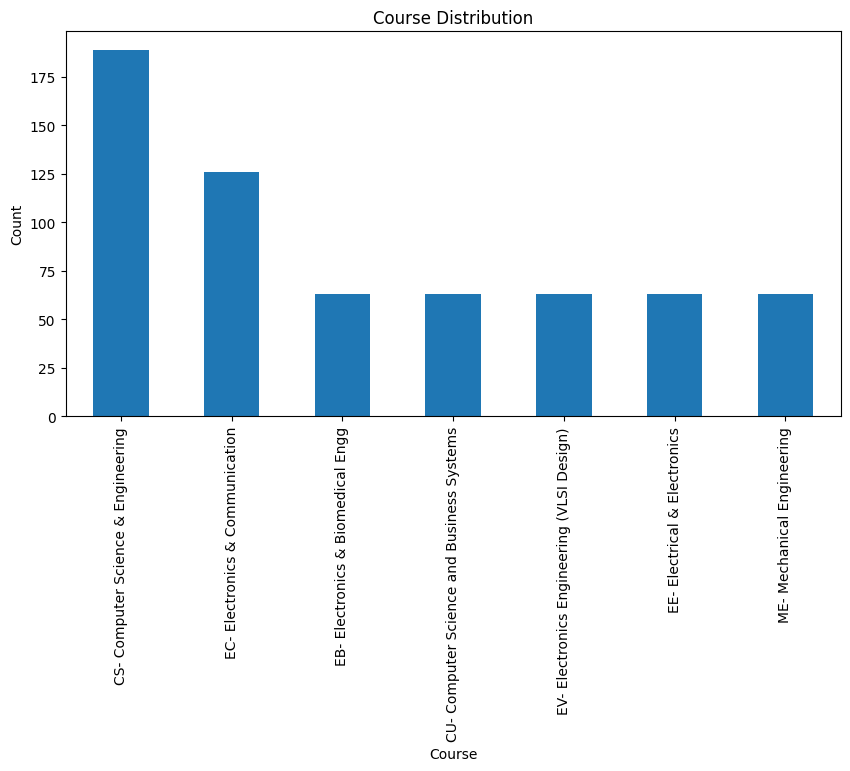

In [11]:
plt.figure(figsize=(10,5))

df['Course'].value_counts().plot(kind='bar')

plt.title("Course Distribution")
plt.xlabel("Course")
plt.ylabel("Count")

plt.show()

In [13]:
df['Category'].value_counts()

Category
GN    354
EZ     79
MU     75
EW     33
SC     31
BH     18
VK     11
LA     10
DV      7
BX      4
KU      3
KN      3
ST      2
Name: count, dtype: int64

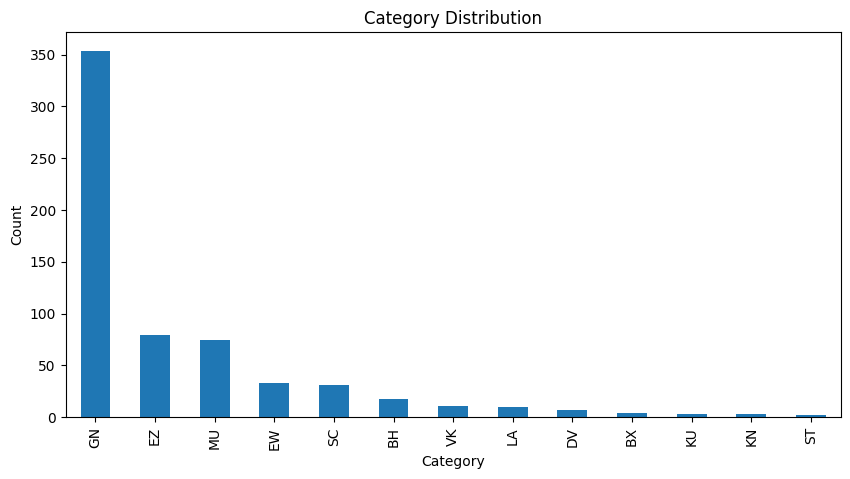

In [14]:
plt.figure(figsize=(10,5))

df['Category'].value_counts().plot(kind='bar')

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [15]:
df['Seat Type'].value_counts()

Seat Type
MG    270
SM    165
EW     34
SC     31
FW     30
EZ     29
MU     26
BH     10
LA      9
VK      7
DV      7
KU      3
BX      3
KN      3
ST      2
PD      1
Name: count, dtype: int64

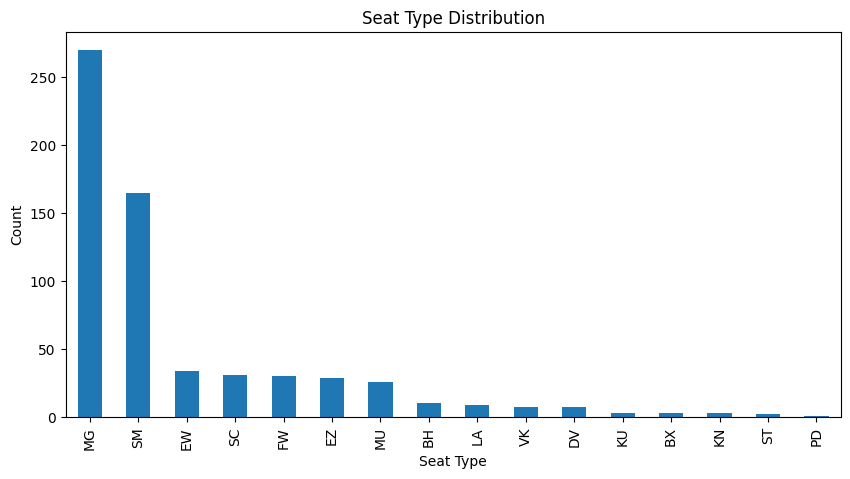

In [16]:
plt.figure(figsize=(10,5))

df['Seat Type'].value_counts().plot(kind='bar')

plt.title("Seat Type Distribution")
plt.xlabel("Seat Type")
plt.ylabel("Count")

plt.show()

In [17]:
df['Keam Rank'].describe()

count      630.000000
mean      7580.663492
std       9178.749571
min        329.000000
25%       2589.000000
50%       4538.500000
75%       8982.500000
max      67069.000000
Name: Keam Rank, dtype: float64

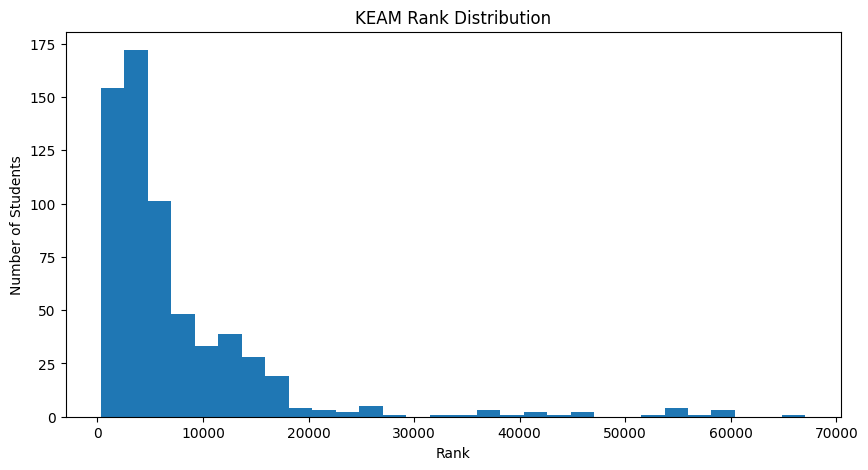

In [18]:
plt.figure(figsize=(10,5))

plt.hist(df['Keam Rank'], bins=30)

plt.title("KEAM Rank Distribution")
plt.xlabel("Rank")
plt.ylabel("Number of Students")

plt.show()

In [19]:
df['Keam Rank'].skew()

np.float64(3.4667239337030153)

In [20]:
df.groupby('Course')['Keam Rank'].agg(
['min','max','mean','median']
)

,min,max,mean,median
Course,,,,
CS- Computer Science & Engineering,329,54935,3394.068783,2261.0
CU- Computer Science and Business Systems,2301,59835,8461.936508,4760.0
EB- Electronics & Biomedical Engg,810,67069,14055.269841,12779.0
EC- Electronics & Communication,635,59028,4690.706349,3491.0
EE- Electrical & Electronics,4006,58852,9510.412698,6995.0
EV- Electronics Engineering (VLSI Design),2917,52015,8715.238095,6816.0
ME- Mechanical Engineering,5137,54049,15500.158730,13623.0


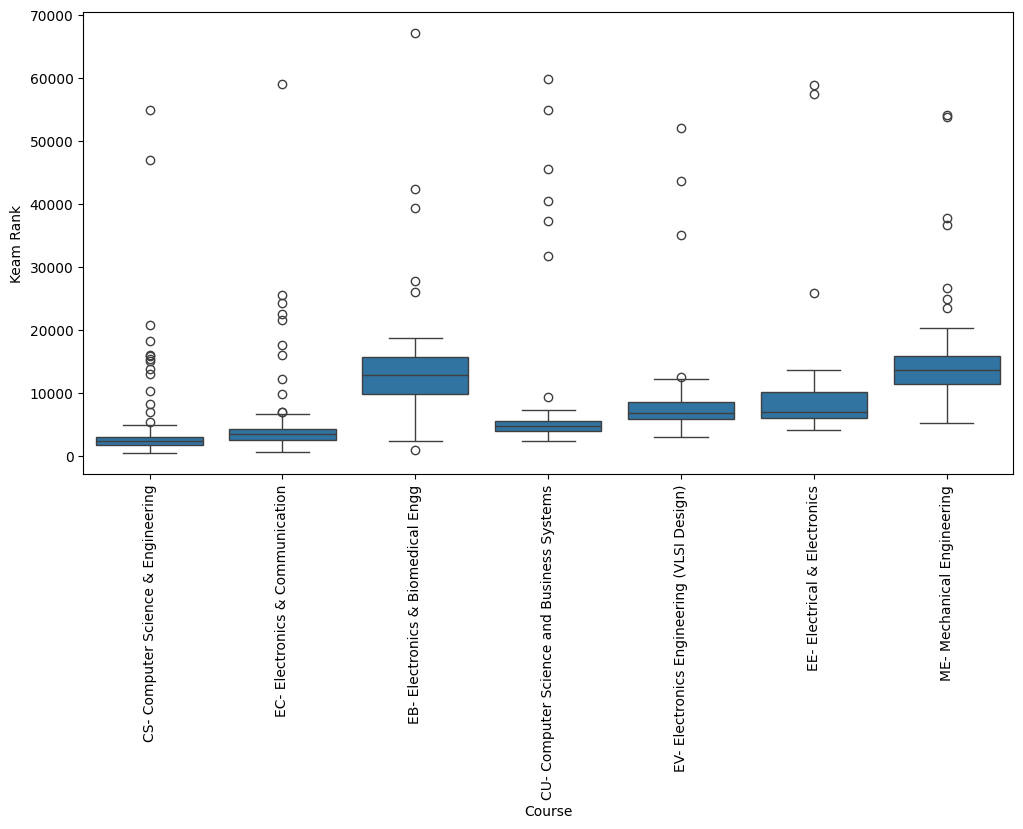

In [21]:
plt.figure(figsize=(12,6))

sns.boxplot(
x='Course',
y='Keam Rank',
data=df
)

plt.xticks(rotation=90)

plt.show()

In [22]:
pd.crosstab(
df['Category'],
df['Course']
)

Course,CS- Computer Science & Engineering,CU- Computer Science and Business Systems,EB- Electronics & Biomedical Engg,EC- Electronics & Communication,EE- Electrical & Electronics,EV- Electronics Engineering (VLSI Design),ME- Mechanical Engineering
Category,,,,,,,
BH,6,1,1,4,2,3,1
BX,2,0,1,1,0,0,0
DV,2,1,0,1,2,0,1
EW,10,3,3,7,3,4,3
EZ,14,5,10,17,10,13,10
GN,124,34,28,71,26,33,38
KN,1,0,0,1,0,1,0
KU,1,0,1,1,0,0,0
LA,2,2,1,2,1,1,1


In [23]:
pd.crosstab(
df['Seat Type'],
df['Course']
)

Course,CS- Computer Science & Engineering,CU- Computer Science and Business Systems,EB- Electronics & Biomedical Engg,EC- Electronics & Communication,EE- Electrical & Electronics,EV- Electronics Engineering (VLSI Design),ME- Mechanical Engineering
Seat Type,,,,,,,
BH,3,1,1,1,1,2,1
BX,1,0,1,1,0,0,0
DV,2,1,0,1,2,0,1
EW,11,3,3,7,3,4,3
EZ,9,2,3,6,3,3,3
FW,9,3,3,6,3,3,3
KN,1,0,0,1,0,1,0
KU,1,0,1,1,0,0,0
LA,2,1,1,2,1,1,1


In [24]:
df.groupby(
['Course','Seat Type']
)['Keam Rank'].max()

Course                              Seat Type
CS- Computer Science & Engineering  BH            2327
                                    BX            6855
                                    DV            4806
                                    EW           54935
                                    EZ            3065
                                                 ...  
ME- Mechanical Engineering          MG           17013
                                    MU           14597
                                    SC           54049
                                    SM           11725
                                    VK           24907
Name: Keam Rank, Length: 85, dtype: int64

In [26]:
# Converts the result to a dictionary for a full view
df.groupby(['Course', 'Seat Type'])['Keam Rank'].max().to_dict()


{('CS- Computer Science & Engineering', 'BH'): 2327,
 ('CS- Computer Science & Engineering', 'BX'): 6855,
 ('CS- Computer Science & Engineering', 'DV'): 4806,
 ('CS- Computer Science & Engineering', 'EW'): 54935,
 ('CS- Computer Science & Engineering', 'EZ'): 3065,
 ('CS- Computer Science & Engineering', 'FW'): 1929,
 ('CS- Computer Science & Engineering', 'KN'): 10242,
 ('CS- Computer Science & Engineering', 'KU'): 5314,
 ('CS- Computer Science & Engineering', 'LA'): 3431,
 ('CS- Computer Science & Engineering', 'MG'): 3466,
 ('CS- Computer Science & Engineering', 'MU'): 2908,
 ('CS- Computer Science & Engineering', 'SC'): 20706,
 ('CS- Computer Science & Engineering', 'SM'): 1673,
 ('CS- Computer Science & Engineering', 'ST'): 47022,
 ('CS- Computer Science & Engineering', 'VK'): 8240,
 ('CU- Computer Science and Business Systems', 'BH'): 4432,
 ('CU- Computer Science and Business Systems', 'DV'): 9304,
 ('CU- Computer Science and Business Systems', 'EW'): 7273,
 ('CU- Computer Scien

In [ ]:
Key Findings

Dataset contains 630 admission records with no missing values.
KEAM ranks show a highly right-skewed distribution (Skewness = 3.47).
CSE is the most competitive branch with a median admitted rank of 2261.
Mechanical Engineering is the least competitive branch with a median admitted rank of 13623.
Significant outliers exist, indicating admissions through special categories and seat allocations.
Rank appears to be the strongest predictor of branch allocation.
GN category dominates the dataset.
Seat-type distribution is imbalanced, with MG seats having the highest representation.

In [27]:
from sklearn.preprocessing import LabelEncoder

df2 = df.copy()

le_course = LabelEncoder()
le_category = LabelEncoder()
le_seat = LabelEncoder()

df2['Course'] = le_course.fit_transform(df2['Course'])
df2['Category'] = le_category.fit_transform(df2['Category'])
df2['Seat Type'] = le_seat.fit_transform(df2['Seat Type'])

In [28]:
corr = df2.corr(numeric_only=True)

corr

,Sl.No,Keam Rank,Category,Course,Seat Type
Sl.No,1.000000,0.715713,0.189075,0.599289,-0.156265
Keam Rank,0.715713,1.000000,0.319899,0.303940,0.006135
Category,0.189075,0.319899,1.000000,-0.012548,0.380242
Course,0.599289,0.303940,-0.012548,1.000000,0.000277
Seat Type,-0.156265,0.006135,0.380242,0.000277,1.000000


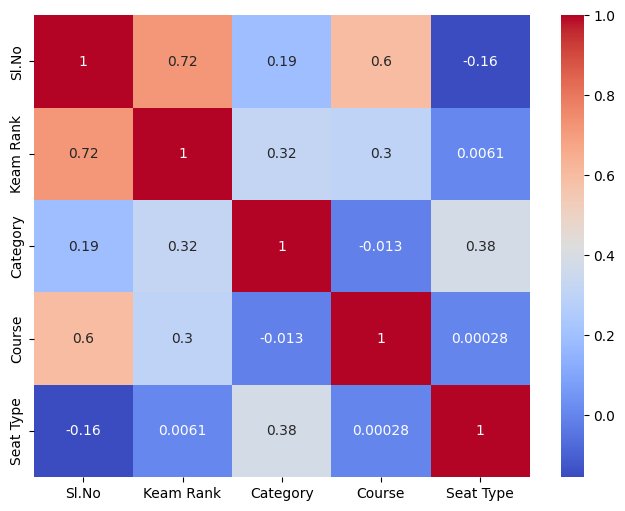

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [30]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [31]:
df_chi = df.copy()

In [32]:
le = LabelEncoder()

df_chi['Category'] = le.fit_transform(df_chi['Category'])
df_chi['Seat Type'] = le.fit_transform(df_chi['Seat Type'])
df_chi['Course'] = le.fit_transform(df_chi['Course'])

In [33]:
X = df_chi[['Keam Rank', 'Category', 'Seat Type']]

In [34]:
y = df_chi['Course']

In [35]:
chi_scores, p_values = chi2(X, y)

In [36]:
chi_results = pd.DataFrame({
    'Feature': X.columns,
    'Chi-Square Score': chi_scores,
    'P-Value': p_values
})

chi_results

,Feature,Chi-Square Score,P-Value
0,Keam Rank,1.493528e+06,0.000000
1,Category,1.126765e+01,0.080448
2,Seat Type,9.946981e-01,0.985813


In [37]:
chi_results.sort_values(
    by='Chi-Square Score',
    ascending=False
)

,Feature,Chi-Square Score,P-Value
0,Keam Rank,1.493528e+06,0.000000
1,Category,1.126765e+01,0.080448
2,Seat Type,9.946981e-01,0.985813


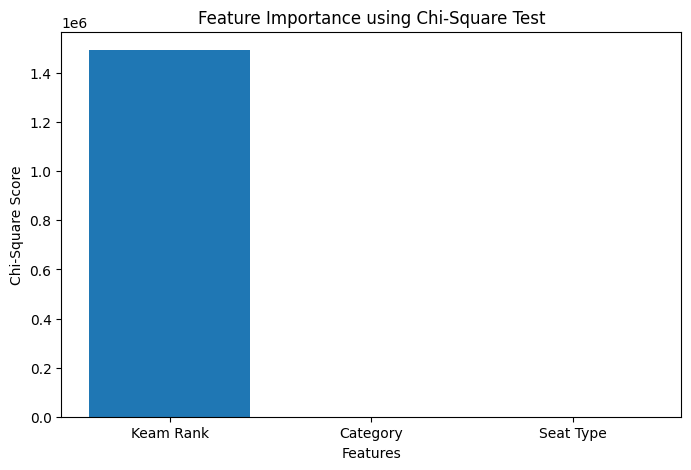

In [38]:
import matplotlib.pyplot as plt

chi_results = chi_results.sort_values(
    by='Chi-Square Score',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    chi_results['Feature'],
    chi_results['Chi-Square Score']
)

plt.title("Feature Importance using Chi-Square Test")
plt.xlabel("Features")
plt.ylabel("Chi-Square Score")

plt.show()